# Genre Classification

In this notebook, machine learning models are trained to classify spotify tracks into genres using their audio features. Since the dataset contains 114 balanced genres, this task evaluates how well audio characteristics distinguish different musical styles.

In [1]:
import pandas as pd
import numpy as np
import joblib

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    top_k_accuracy_score
)

## Load Feature Engineered Dataset

In [2]:
df = pd.read_csv("../data/processed/features_dataset.csv")

## Define Features and Target Variables

In [3]:
FEATURES = [
    "danceability",
    "energy",
    "key",
    "loudness",
    "mode",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo",
    "duration_min",
    "time_signature",
    "explicit"
]

X = df[FEATURES]

y = df["genre_encoded"]

## Split Dataset

The dataset is divided into training and testing sets using stratified sampling to ensure every genre is represented proportionally in both sets.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Standardize Features

Feature scaling ensures that all input variables have comparable ranges before model training.

In [5]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

joblib.dump(
    scaler,
    "../models/scaler.pkl"
)

['../models/scaler.pkl']

## Train Random Forest Classifier

In [ ]:
clf = RandomForestClassifier(
    n_estimators=150,
    max_depth=14,
    random_state=42,
    n_jobs=-1
)

clf.fit(
    X_train_scaled,
    y_train
)

pred = clf.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, pred))

## Observation

The Random Forest Classifier learns complex relationships between Spotify audio features and music genres. The reported accuracy provides the Top-1 prediction performance.

## Top-5 Accuracy

With 114 genres, predicting the exact genre is challenging. Top-5 accuracy measures whether the correct genre appears among the model's five most confident predictions.

In [7]:
proba = clf.predict_proba(
    X_test_scaled
)

print(
    "Top-1 accuracy:",
    accuracy_score(y_test, pred)
)

print(
    "Top-5 accuracy:",
    top_k_accuracy_score(
        y_test,
        proba,
        k=5,
        labels=clf.classes_
    )
)

Top-1 accuracy: 0.35864720303097836
Top-5 accuracy: 0.6139402718965902


## Observation

Top-5 accuracy provides a more realistic evaluation for multi-class problems with many similar genres, where several predictions may be musically plausible.

## Confusion Matrix

To keep the visualization readable, the confusion matrix is restricted to eight commonly recognized genres.

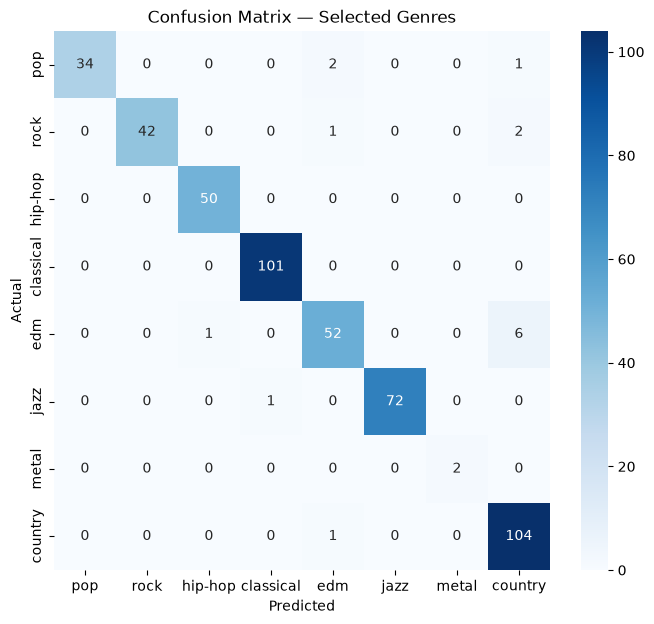

In [8]:
le_genre = joblib.load(
    "../models/genre_label_encoder.pkl"
)

top_genre_names = [
    "pop",
    "rock",
    "hip-hop",
    "classical",
    "edm",
    "jazz",
    "metal",
    "country"
]

top_genre_ids = le_genre.transform(
    top_genre_names
)

mask = np.isin(
    y_test,
    top_genre_ids
)

cm = confusion_matrix(
    y_test[mask],
    pred[mask],
    labels=top_genre_ids
)

plt.figure(figsize=(8,7))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=top_genre_names,
    yticklabels=top_genre_names,
    cmap="Blues"
)

plt.title(
    "Confusion Matrix — Selected Genres"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.savefig(
    "../reports/figures/genre_confusion_matrix.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

### Observation

The confusion matrix highlights which genres are frequently confused with one another. Similar genres often overlap in their audio characteristics, making classification more difficult.

## Save Trained Model

In [ ]:
joblib.dump(
    clf,
    "../models/genre_model.pkl",
    compress=9
)